In [1]:
class V:
    ica_data = []

In [2]:
import mne

# 读取 EDF 文件
file_path = "sub2.edf"
raw = mne.io.read_raw_edf(file_path, preload=True)

data, times = raw[:]

# 打印信息
print("通道名称:", raw.ch_names)
print("采样率:", raw.info["sfreq"])
print("数据形状:", data.shape)  # (通道数, 采样点数)


Extracting EDF parameters from D:\AAD\p\sub2.edf...
EDF file detected


ValueError: could not convert string to float: '        '

In [22]:
# from scipy.io import savemat
# savemat('baseline_rs.mat',{'data':np.transpose(np.load(subname+'_tACS_baseline_rs.npy'),axes=(1,0))/1000})

In [1]:
import numpy as np
eeg_data = []
file_path = 'E:/原始数据/NE/liyuxiao/20240118110417_liyuxiao-1.easy'
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()
    for line in lines:
        # print(line.strip())
        numbers = [int(num) for num in line.strip().split()]
        eeg_data.append(numbers)
# print(np.array(eeg_data).shape, np.array(eeg_data)[:,0])
# np.save('zengyun'+'_baseline.npy', eeg_data)
# eeg_data = np.transpose(np.array(eeg_data),axes=(1,0))/1000

In [2]:
start_list = np.where(np.transpose(np.array(eeg_data))[-2,:]==1)
end_list = np.where(np.transpose(np.array(eeg_data))[-2,:]==2)

In [3]:
len(start_list[0])

16

In [4]:
eeg_data = np.array(eeg_data).transpose()[:32]

In [5]:
eeg_data.shape

(32, 819724)

In [6]:
import  mne
n_channels = eeg_data.shape[0]
sfreq = 500
ch_names = ['P8', 'T8', 'CP6', 'FC6', 'F8', 'F4', 'C4', 'P4', 'AF4', 'Fp2', 'Fp1', 'AF3', 'Fz', 'FC2',
                     'Cz', 'CP2', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'Pz', 'CP1', 'FC1', 'P3', 'C3', 'F3', 'F7', 'FC5',
                     'CP5', 'T7', 'P7']
info = mne.create_info(ch_names, sfreq, ch_types='eeg')
info.set_montage('standard_1020')
raw = mne.io.RawArray(eeg_data, info)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "D:\anaconda3\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "D:\anaconda3\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "D:\anaconda3\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "D:\anaconda3\lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "D:\anaconda3\lib\site-packages\ipykernel\kernelapp.py", line 711, in start
    self.io

AttributeError: _ARRAY_API not found

Creating RawArray with float64 data, n_channels=32, n_times=819724
    Range : 0 ... 819723 =      0.000 ...  1639.446 secs
Ready.


In [7]:
raw.set_eeg_reference(ref_channels='average')
raw.notch_filter(freqs=[50, 100, 150])
raw.filter(l_freq=30, h_freq=100, fir_design='firwin')  # 0.5Hz 高通, 40Hz 低通
# raw.resample(sfreq=200)
processed_data = raw.get_data()

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 3301 samples (6.602 s)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.2s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 30 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 30.00
- Lower transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 26.25 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 221 samples (0.442 s)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s


In [8]:
processed_data.shape

(32, 819724)

In [9]:
eeg_data = processed_data

In [10]:
start_list

(array([  8035,  59995, 112051, 170752, 222342, 273772, 324703, 375726,
        426369, 477715, 529224, 581399, 633626, 684377, 734722, 784754]),)

In [11]:
d = []
l = [0,0,1,1,0,1,0,1,0,1,1,0]
label = []
k = 0
for i in range(len(start_list[0])):
    data = np.array(eeg_data)[:,start_list[0][i]:start_list[0][i]+35000]
    if i!=len(start_list[0])-1:
        print(end_list[0][i]-start_list[0][i])
    if i not in [0, 3, 6, 13]:
        label.append([l[k]]*69)
        k+=1
        for j in range(69):
            d.append(data[:,j*500:(j+1)*500])

print(np.array(d).shape, np.array(label).shape)

35001
35002
35001
35000
35001
35000
35001
35000
35001
35000
35000
35000
35000
35001
35001
(828, 32, 500) (12, 69)


In [12]:
print(np.array(d).shape, np.array(label).shape)

(828, 32, 500) (12, 69)


In [13]:
(processed_data.shape[1]/500)/16

102.4655

In [14]:
35000/500

70.0

In [49]:
np.save('sub2.npy', np.array(d))
np.save('sub2_label.npy', np.array(label).flatten())

In [32]:
import numpy as np
np.load('sub2_label.npy').shape

(828,)

In [ ]:
import numpy as np
eeg_data = []
file_path = 'E:/原始数据/NE/liyuxiao/20240118110417_liyuxiao-1.easy'
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()
    for line in lines:
        # print(line.strip())
        numbers = [int(num) for num in line.strip().split()]
        eeg_data.append(numbers)
# print(np.array(eeg_data).shape, np.array(eeg_data)[:,0])
# np.save('zengyun'+'_baseline.npy', eeg_data)
# eeg_data = np.transpose(np.array(eeg_data),axes=(1,0))/1000

In [ ]:
start_list = np.where(np.transpose(np.array(eeg_data))[-2,:]==1)
end_list = np.where(np.transpose(np.array(eeg_data))[-2,:]==2)

In [6]:
d = []
l = [0,0,1,1,0,1,0,1,0,1,1,0]
label = []
k = 0
for i in range(len(start_list[0])):
    data = np.transpose(np.array(eeg_data))[:32,start_list[0][i]:start_list[0][i]+35000]/1000
    if i!=len(start_list[0])-1:
        print(end_list[0][i]-start_list[0][i])
    if i not in [0, 3, 6, 13]:
        label.append([l[k]]*69)
        k+=1
        for j in range(69):
            d.append(data[:,j*500:(j+1)*500])

print(np.array(d).shape, np.array(label).shape)

35001
35002
35001
35000
35001
35000
35001
35000
35001
35000
35000
35000
35000
35001
35001
(828, 32, 500) (12, 69)


In [7]:
np.save('sub2.npy', np.array(d))
np.save('sub2_label.npy', np.array(label))

In [8]:
np.array(label)

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [7]:
69*12

828

In [6]:
trials_num = np.array(list(d.values()))

AttributeError: 'list' object has no attribute 'values'

In [ ]:
print(np.array(d).shape)

In [4]:
import numpy as np
eeg_data = []
file_path = 'E:/实验数据+标签/被试2——李昱晓/record/trial_'
for i in range(16):
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
        for line in lines:

SyntaxError: incomplete input (3944355655.py, line 7)

In [2]:
from scipy.io import savemat
import numpy as np
savemat('sub2.mat',{'data':np.hstack([np.array(eeg_data)[:,:32], np.expand_dims(np.array(eeg_data)[:,35], axis=-1)])})

In [3]:
np.hstack([np.array(eeg_data)[:,:32], np.expand_dims(np.array(eeg_data)[:,35], axis=-1)])[0,-1]

np.int64(0)

In [4]:

for i in range(len(start_list[0])):
    data = np.transpose(np.array(eeg_data))[:32,start_list[0][i]:end_list[0][i]]/1000
    savemat('sub2.mat',{'data':data})

IndexError: index 15 is out of bounds for axis 0 with size 15

In [3]:
start_list

(array([  8035,  59995, 112051, 170752, 222342, 273772, 324703, 375726,
        426369, 477715, 529224, 581399, 633626, 684377, 734722, 784754]),)

In [42]:
import numpy as np
eeg_data = []
file_path = 'C:/Users/itsyu/Documents/NIC/20241225104249_曾云_bp.easy'
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()
    for line in lines:
        # print(line.strip())
        numbers = [int(num) for num in line.strip().split()]
        eeg_data.append(numbers)
print(np.array(eeg_data).shape, np.array(eeg_data)[:,0])
np.save('zengyun'+'_baseline.npy', eeg_data)
# eeg_data = np.transpose(np.array(eeg_data),axes=(1,0))/1000

(338000, 37) [33137039 33128408 33128646 ... 32818559 32822183 32820276]


In [43]:
start_list = np.where(np.transpose(np.array(eeg_data))[-2,:]==1)
end_list = np.where(np.transpose(np.array(eeg_data))[-2,:]==2)

In [44]:
from scipy.io import savemat
import numpy as np
for i in range(len(start_list[0])):
    data = np.transpose(np.array(eeg_data))[:32,start_list[0][i]:end_list[0][i]]/1000
    savemat('tACS_data/zengyun/baseline/zengyun'+'_baseline_trail_'+str(i+1)+'.mat',{'data':data})

In [37]:
len(start_list[0])

31

In [38]:
np.transpose(np.array(eeg_data)).shape

(37, 391531)

In [46]:
np.array([1,2,3])-np.array([1,1,1])

array([0, 1, 2])

In [1]:
import mne

raw = mne.io.read_raw_eeglab('P1'+'_task.set', preload=True)
channel_names = ['C3', 'C4', 'Cz']
raw_selected = raw.pick_channels(channel_names)

Reading D:\AAD\p\P1_task.fdt
Reading 0 ... 167312  =      0.000 ...   334.624 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


In [2]:
raw.info['ch_names'].index('C3')

0

f range: 0.0 Hz to 250.0 Hz
f step: 1.0 Hz


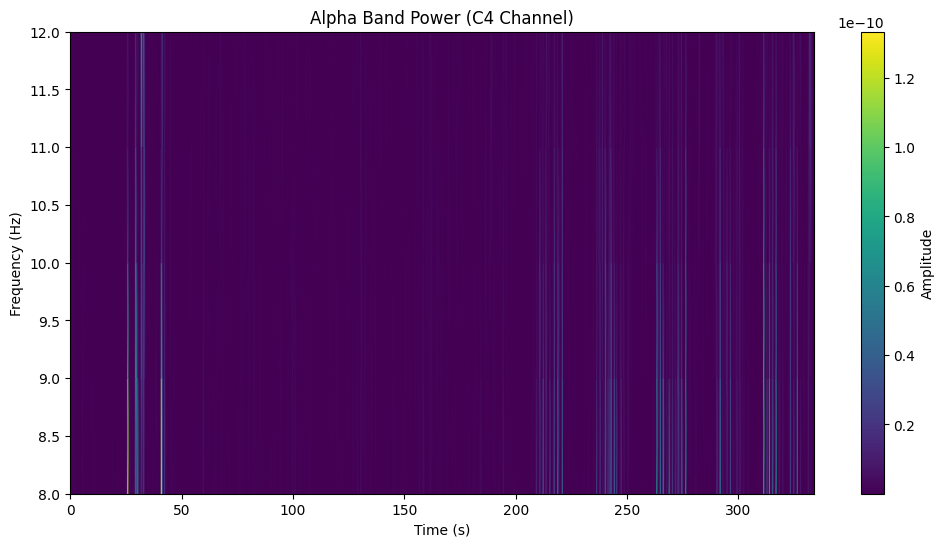

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

f, t, Zxx = stft(raw_selected.get_data()[:,:334*500], fs=500, nperseg=500)

print(f"f range: {f[0]} Hz to {f[-1]} Hz")
print(f"f step: {f[1] - f[0]} Hz")

alpha_mask = (f >= 8) & (f <= 12)

# alpha_amplitude = np.abs(Zxx[:,alpha_mask, :])**2
alpha_amplitude = np.real(Zxx[:, alpha_mask, :])**2 + np.imag(Zxx[:, alpha_mask, :])**2 



plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f[alpha_mask], alpha_amplitude[1, :, :], shading='gouraud')
plt.colorbar(label='Amplitude')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Alpha Band Power (C4 Channel)')
plt.show()




In [49]:
 raw_selected.get_data().shape[1]/500

334.626

In [30]:
Zxx.shape

(3, 251, 671)

Creating RawArray with float64 data, n_channels=32, n_times=167313
    Range : 0 ... 167312 =      0.000 ...   334.624 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (1.650 s)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.0s finished


<IPython.core.display.Javascript object>


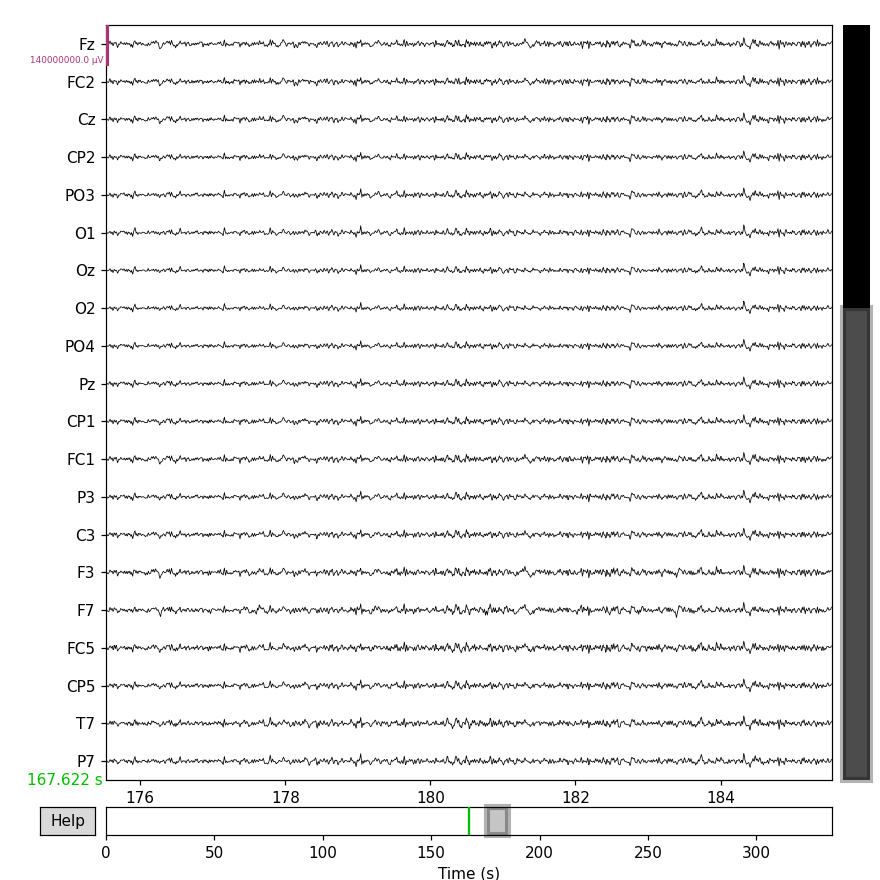

<IPython.core.display.Javascript object>


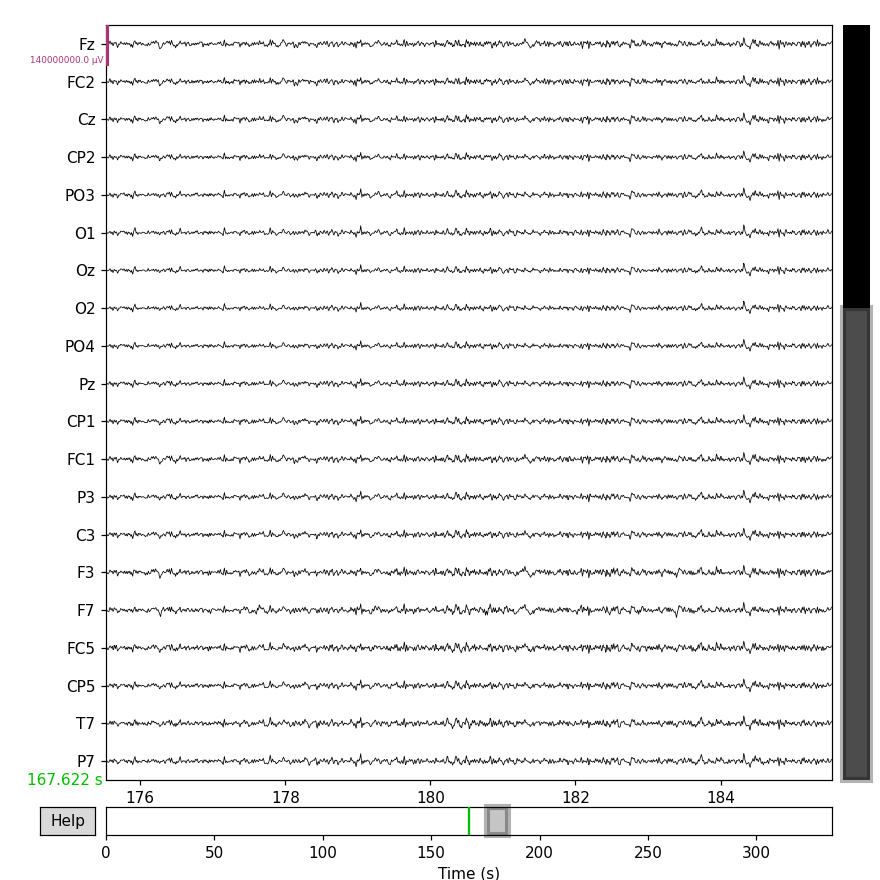

In [9]:
import mne
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from scipy.signal import welch
%matplotlib notebook

n_channels = eeg_data.shape[0]
sfreq = 500
ch_names = ['P8', 'T8', 'CP6', 'FC6', 'F8', 'F4', 'C4', 'P4', 'AF4', 'Fp2', 'Fp1', 'AF3', 'Fz', 'FC2',
                     'Cz', 'CP2', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'Pz', 'CP1', 'FC1', 'P3', 'C3', 'F3', 'F7', 'FC5',
                     'CP5', 'T7', 'P7']
info = mne.create_info(ch_names, sfreq, ch_types='eeg')
info.set_montage('standard_1020')
raw = mne.io.RawArray(eeg_data, info)
#     mne.export.export_raw('rs_baseline', raw, fmt="edf")
raw.filter(l_freq=4, h_freq=40)
raw.plot(scalings={'eeg': 70})

In [10]:

#
#
#
#
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from scipy.signal import welch
%matplotlib notebook

channels_list = ['P8', 'T8', 'CP6', 'FC6', 'F8', 'F4', 'C4', 'P4', 'AF4', 'Fp2', 'Fp1', 'AF3', 'Fz', 'FC2',
                 'Cz', 'CP2', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'Pz', 'CP1', 'FC1', 'P3', 'C3', 'F3', 'F7', 'FC5',
                 'CP5', 'T7', 'P7']
subname = 'P1'
original_file_path = '../tACS/'

channels = 32
num_segments = 69
freq = 500
eeg_data = []
# file_path = original_file_path+subname+'/20241105211739_程威瑞_bp.easy'
# with open(file_path, 'r', encoding='utf-8') as file:
#     lines = file.readlines()
#     for line in lines:
#         # print(line.strip())
#         numbers = [int(num) for num in line.strip().split()]
#         eeg_data.append(numbers[:-5])
# print(np.array(eeg_data).shape, np.array(eeg_data)[:,0])
# np.save(subname+'_tACS_post_task.npy', eeg_data)


rs_baseline = np.transpose(np.load('P1_task.npy'),axes=(1,0))
# task_baseline = np.transpose(np.load(subname+'_tACS_baseline_task.npy'),axes=(1,0))

print(rs_baseline.shape)
def sort_ica_components_by_energy(ica, raw):
    sources = ica.get_sources(raw).get_data()
    # variances = np.var(sources, axis=1)
#     v = np.mean(np.abs(sources), axis=1)
    v = np.mean(sources**2, axis=1)
    sorted_indices = np.argsort(v)[::-1]
    return sorted_indices, v[sorted_indices]
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def plot_ic_spectra(ica, raw, sorted_indices,sfreq=500):
    sources = ica.get_sources(raw).get_data()
    n_ics, n_samples = sources.shape
    fig, axes = plt.subplots(n_ics // 4 + 1, 4, figsize=(15, n_ics * 2))

    for i, source in enumerate(sources):
        ax = axes[i // 4, i % 4]
        freqs = fftfreq(n_samples, 1/sfreq)[:n_samples // 2]
        power_spectrum = np.abs(fft(source))[:n_samples // 2] ** 2

        ax.plot(freqs, power_spectrum, color='blue')
        ax.set_title(f"IC {i+1} Spectrum")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power")
        ax.set_xlim(4, 48)

    plt.tight_layout()
    plt.show()

def plot_PSD(ica_sources, idx, i):

    freqs, psd = welch(ica_sources[idx], fs=500, nperseg=250)
    psd_log = 10 * np.log10(psd * 1e6)  # 转换为 μV²/Hz
    mask = freqs<=80
    plt.plot(freqs[mask], psd_log[mask], color='r')

    # plt.plot(freqs, psd_log, color='r')
    # plt.xlim(0,80)
    plt.xlabel('Frequency (Hz)')
    if i%4==0:
        plt.ylabel('Power (10*log10(uV²/Hz))')
    plt.title(f'IC  00{idx} - PS')
    # plt.show()


def preprocessing(eeg_data):
    n_channels = eeg_data.shape[0]
    sfreq = 500
    ch_names = ['P8', 'T8', 'CP6', 'FC6', 'F8', 'F4', 'C4', 'P4', 'AF4', 'Fp2', 'Fp1', 'AF3', 'Fz', 'FC2',
                         'Cz', 'CP2', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'Pz', 'CP1', 'FC1', 'P3', 'C3', 'F3', 'F7', 'FC5',
                         'CP5', 'T7', 'P7']
    info = mne.create_info(ch_names, sfreq, ch_types='eeg')
    info.set_montage('standard_1020')
    raw = mne.io.RawArray(eeg_data, info)
#     mne.export.export_raw('rs_baseline', raw, fmt="edf")
    raw.filter(l_freq=4, h_freq=40)

    ica = ICA(n_components=32, random_state=97, max_iter=800, method='infomax', fit_params={'extended':True})
    ica.fit(raw)
    data = ica.get_sources(raw).get_data()
    V.ica_data = data
    sorted_indices, sorted_variances = sort_ica_components_by_energy(ica, raw)
    ica.plot_components(picks=sorted_indices)
#     plot_ic_spectra(ica, raw, sorted_indices)

    # eog_indices, _ = ica.find_bads_eog(raw,ch_names=['Fp1','Fp2'])
    # ica.exclude = eog_indices

    ica.plot_sources(raw, picks=sorted_indices)
    # ica.plot_components()
    plt.subplots(8, 4, figsize=(9,16))
    for i in range(len(sorted_indices)):

        # ica.plot_components(picks=sorted_indices[i], show=False)
        # ica.plot_sources(raw, picks=sorted_indices[i], show=False)
        # Subplot 3: Time-Frequency Plot
        # axs[1,0] = get_time_frequency(data, sorted_indices[i])
        # axs[1,0].title("Time-Frequency Plot")
        plt.subplot(8, 4, i+1)
        plot_PSD(data, sorted_indices[i], i)
        plt.axvline(x=10, color='green', linestyle='--')

    plt.tight_layout()
    plt.show()


    return raw, ica

raw1, ica1 = preprocessing(rs_baseline/1000)
# plt.plot(preprocessing(rs_baseline))
# plt.axis('off')
# plt.show()


# plt.plot(preprocessing(task_baseline))
# plt.axis('off')
# plt.show()

(32, 167313)
Creating RawArray with float64 data, n_channels=32, n_times=167313
    Range : 0 ... 167312 =      0.000 ...   334.624 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (1.650 s)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.1s finished


Fitting ICA to data using 32 channels (please be patient, this may take a while)
Selecting by number: 32 components
Computing Extended Infomax ICA
Fitting ICA took 254.7s.


NameError: name 'V' is not defined

(32, 222141)
Creating RawArray with float64 data, n_channels=32, n_times=242298
    Range : 0 ... 242297 =      0.000 ...   484.594 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (1.650 s)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:    0.0s remaining:    0.0s


Fitting ICA to data using 32 channels (please be patient, this may take a while)


[Parallel(n_jobs=1)]: Done  32 out of  32 | elapsed:    0.2s finished


Selecting by number: 32 components
Computing Extended Infomax ICA
Fitting ICA took 453.0s.


<IPython.core.display.Javascript object>


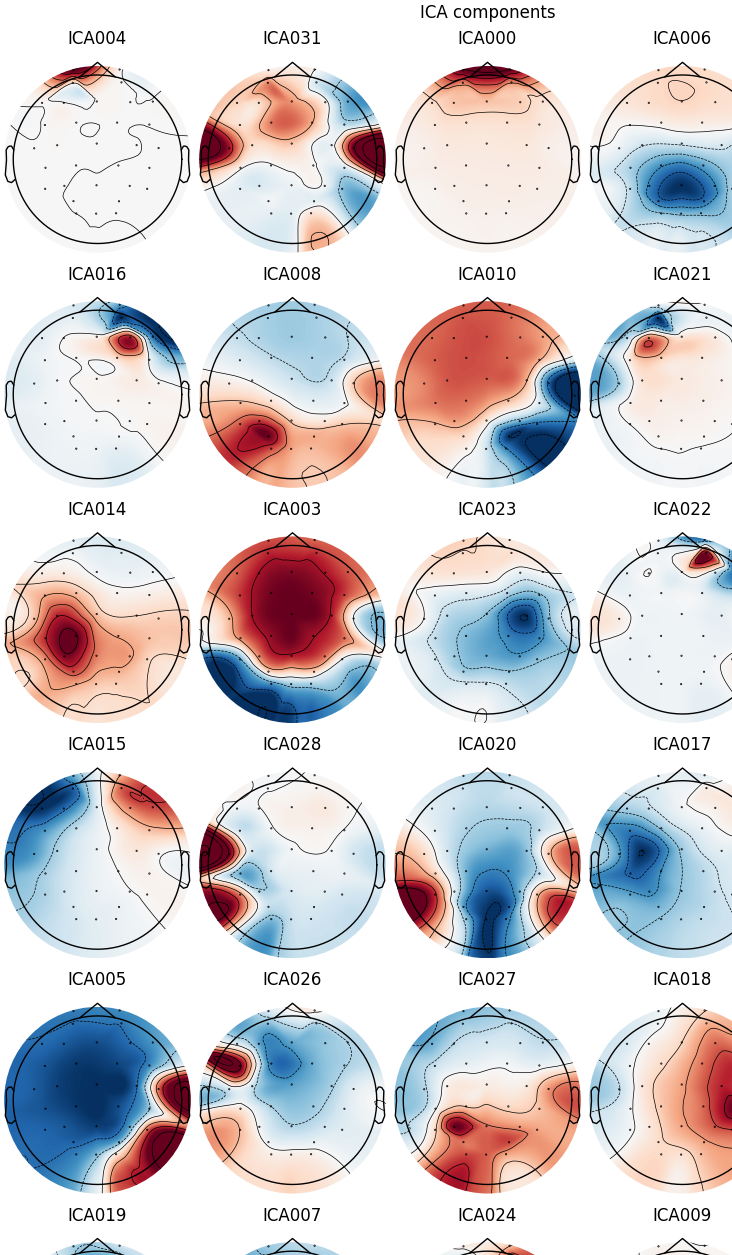

Creating RawArray with float64 data, n_channels=32, n_times=242298
    Range : 0 ... 242297 =      0.000 ...   484.594 secs
Ready.


<IPython.core.display.Javascript object>


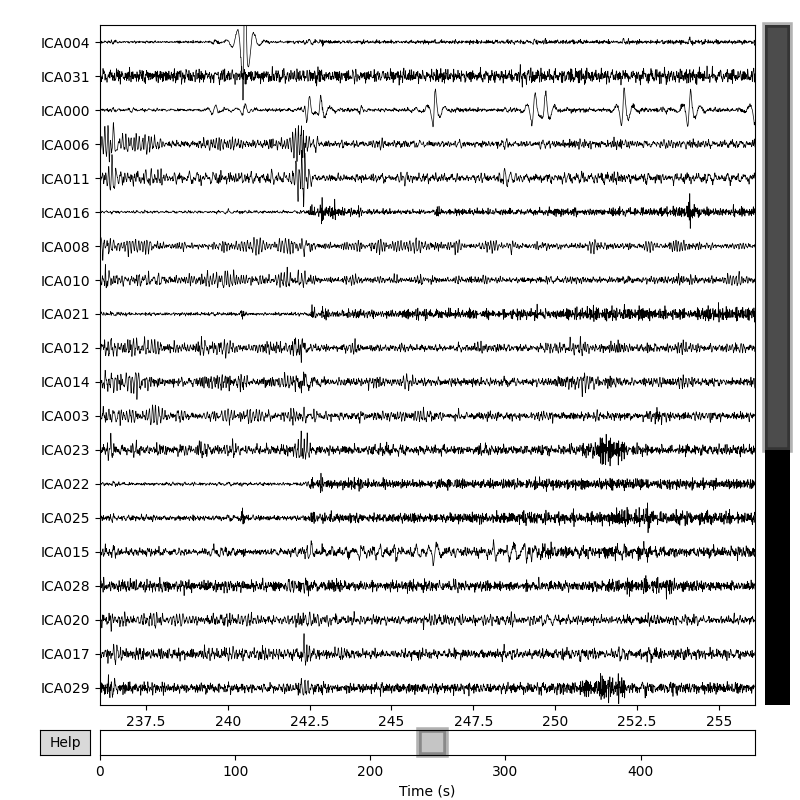

<IPython.core.display.Javascript object>


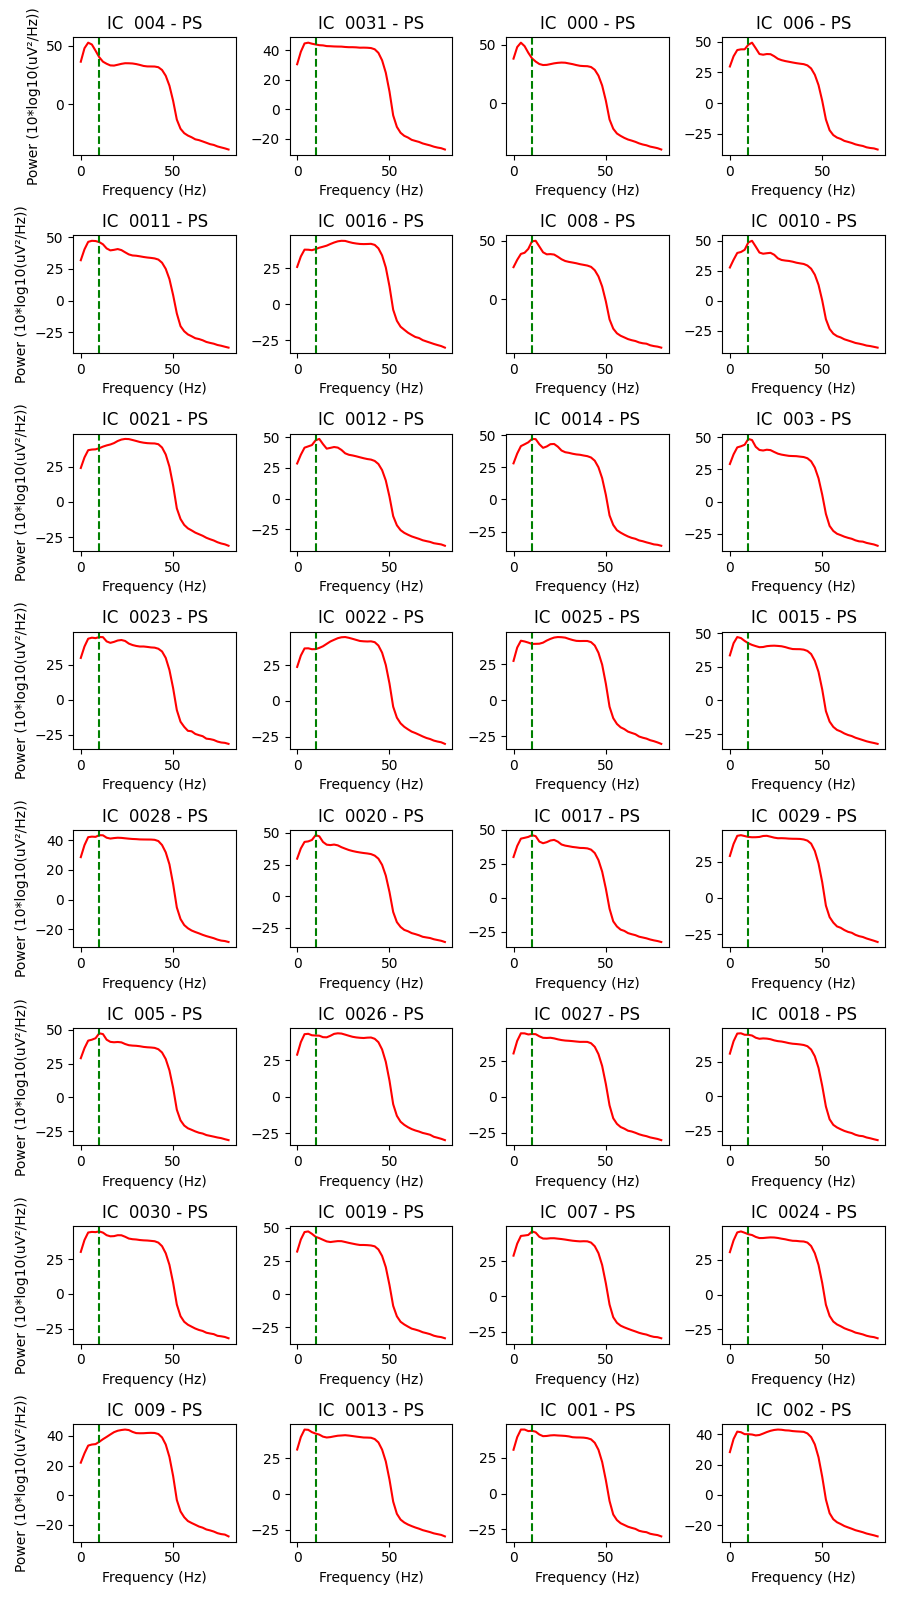

In [13]:
raw2, ica2 = preprocessing(task_baseline/1000)

In [10]:
def processing2(ica,raw, p):
    ica.exclude = [6,11,23]
    raw_clean = ica.apply(raw)
    print(raw_clean.info['ch_names'])
    raw_clean.set_eeg_reference('average', projection=True)
    np.save(p, raw_clean.get_data())

processing2(ica1, raw1, '../tACS/rs_baseline_pre.npy')

Applying ICA to Raw instance
    Transforming to ICA space (32 components)
    Zeroing out 3 ICA components
    Projecting back using 32 PCA components
['P8', 'T8', 'CP6', 'FC6', 'F8', 'F4', 'C4', 'P4', 'AF4', 'Fp2', 'Fp1', 'AF3', 'Fz', 'FC2', 'Cz', 'CP2', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'Pz', 'CP1', 'FC1', 'P3', 'C3', 'F3', 'F7', 'FC5', 'CP5', 'T7', 'P7']
EEG channel type selected for re-referencing


C:\Users\itsyu\AppData\Local\Temp\ipykernel_6204\215304967.py:5: RuntimeWarning: An average reference projection was already added. The data has been left untouched.
  raw_clean.set_eeg_reference('average', projection=True)


In [11]:
processing2(ica2, raw2, '../tACS/task_baseline_pre.npy')

NameError: name 'ica2' is not defined

In [3]:
 3 10 25
15 28 22 21

SyntaxError: invalid syntax (2183446927.py, line 1)

In [ ]:
np.sum(V.ica_data, axis=1)